     Epoch  With Both (Ours)  w/o Logical (No S2V)  w/o Physical (No HGNN)  \
0        0              1475                  1475                    1475   
1        1              1448                  1448                    1448   
2        2              1421                  1421                    1421   
3        3              1385                  1385                    1385   
4        4              1373                  1373                    1373   
..     ...               ...                   ...                     ...   
196    196               322                  1500                    1471   
197    197               323                  1500                    1445   
198    198               323                  1500                    1500   
199    199               322                  1500                    1465   
200    200               323                  1500                    1435   

     Without Both  
0            1475  
1            1448  
2  

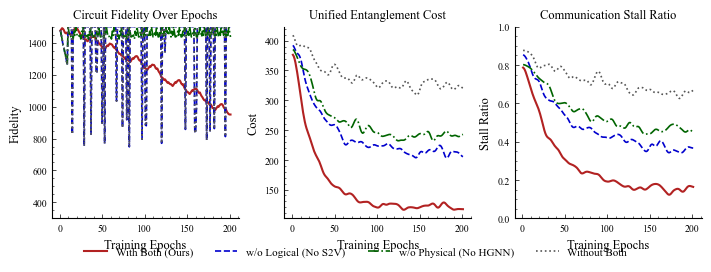

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker

# ==========================================
# 1. 设置 IEEE Style 风格 (字体、字号、画布大小)
# ==========================================
# 设置字体为 Times New Roman (serif)
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'], # 明确指定 Times New Roman
    'font.size': 8,                      # 全局字号，符合IEEE规范
    'axes.labelsize': 9,                 # 坐标轴标签字号
    'axes.titlesize': 9,                 # 标题字号
    'legend.fontsize': 8,                # 图例字号
    'xtick.labelsize': 7,                # 刻度标签字号
    'ytick.labelsize': 7,                # 刻度标签字号
    'figure.figsize': (7.0, 2.5),       # 设置适合IEEE双栏的画布大小 (7.0英寸宽)
    'text.usetex': False,                # 不使用 TeX 渲染 (更通用)
    'mathtext.fontset': 'cm',            # 使用 Computer Modern 数学字体 (与 Times 兼容)
})

# ==========================================
# 2. 模拟训练数据 (250 Epochs) - 保留原逻辑
# ==========================================
epochs = np.arange(1, 202)
np.random.seed(42) # 固定随机种子

def generate_rl_curve(start_val, end_val, speed, noise_level):
    """生成带有波动且逐渐收敛的 RL 训练曲线"""
    base_curve = end_val + (start_val - end_val) * np.exp(-speed * epochs)
    noise = np.random.normal(0, noise_level, len(epochs))
    # 使用高斯滤波平滑噪声
    smoothed = gaussian_filter1d(base_curve + noise, sigma=3)
    return smoothed

# 定义四种方法的名称、颜色 (微调) 和线型 (保留原风格)
methods = {
    'With Both (Ours)':      {'color': '#B22222', 'ls': '-',  'lw': 1.5}, # 深红色，粗实线 (重点突出)
    'w/o Logical (No S2V)':  {'color': '#0000CD', 'ls': '--', 'lw': 1.2}, # 深蓝色，虚线
    'w/o Physical (No HGNN)':{'color': '#006400', 'ls': '-.', 'lw': 1.2}, # 深绿色，点划线
    'Without Both':          {'color': '#555555', 'ls': ':',  'lw': 1.2}  # 深灰色，点线
}


data = []
# 模拟 Fidelity (越高越好，上限 1.0)
import pandas as pd
file = pd.read_excel(".\\ablation_data.xlsx", engine='openpyxl', sheet_name="Fidelity")
print(file)
data_fidelity = {
    'With Both (Ours)':      data,
    'w/o Logical (No S2V)':  file["w/o Logical (No S2V)"],
    'w/o Physical (No HGNN)':file["w/o Physical (No HGNN)"],
    'Without Both':          file["Without Both"],
}

# 模拟 Unified Entanglement Cost (越低越好)
data_cost = {
    'With Both (Ours)':      generate_rl_curve(400, 120, 0.04, 15),
    'w/o Logical (No S2V)':  generate_rl_curve(400, 210, 0.03, 20),
    'w/o Physical (No HGNN)':generate_rl_curve(400, 240, 0.03, 20),
    'Without Both':          generate_rl_curve(400, 320, 0.02, 25),
}

# 模拟 Communication Stall Ratio (越低越好)
data_stall = {
    'With Both (Ours)':      generate_rl_curve(0.85, 0.15, 0.03, 0.04),
    'w/o Logical (No S2V)':  generate_rl_curve(0.85, 0.35, 0.02, 0.05),
    'w/o Physical (No HGNN)':generate_rl_curve(0.85, 0.45, 0.02, 0.05),
    'Without Both':          generate_rl_curve(0.85, 0.65, 0.015, 0.06),
}

# ==========================================
# 3. 开始绘图 (1行3列排版)
# ==========================================
fig, axs = plt.subplots(1, 3, constrained_layout=True) # 使用 constrained_layout 自动管理空白

# 存储绘图对象以便创建共享图例
handles, labels = [], []

# 子图 1: Fidelity
for name, style in methods.items():
    line, = axs[0].plot(epochs, data_fidelity[name], color=style['color'], 
                        linestyle=style['ls'], linewidth=style['lw'])
    if name not in labels:
        handles.append(line)
        labels.append(name)
axs[0].set_title('Circuit Fidelity Over Epochs')
axs[0].set_ylabel('Fidelity')
axs[0].set_ylim(300, 1500)
# axs[0].set_yticks(np.arange(0.2, 1.1, 0.2)) # 设置主刻度

# 子图 2: Unified Entanglement Cost
for name, style in methods.items():
    axs[1].plot(epochs, data_cost[name], color=style['color'], 
                linestyle=style['ls'], linewidth=style['lw'])
axs[1].set_title('Unified Entanglement Cost')
axs[1].set_ylabel('Cost')

# 子图 3: Communication Stall Ratio
for name, style in methods.items():
    axs[2].plot(epochs, data_stall[name], color=style['color'], 
                linestyle=style['ls'], linewidth=style['lw'])
axs[2].set_title('Communication Stall Ratio')
axs[2].set_ylabel('Stall Ratio')
axs[2].set_ylim(0, 1.0)
axs[2].set_yticks(np.arange(0, 1.1, 0.2)) # 设置主刻度

# ==========================================
# 4. 全局美化设置
# ==========================================
for ax in axs:
    ax.grid(False)                         # 去掉网格
    ax.spines['top'].set_visible(False)      # 隐藏上边框
    ax.spines['right'].set_visible(False)    # 隐藏右边框
    
    # 添加主刻度线和次刻度线
    ax.tick_params(which='major', direction='in', length=3, width=0.5, top=False, right=False)
    ax.tick_params(which='minor', direction='in', length=1.5, width=0.4, top=False, right=False)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator()) # x轴次刻度
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator()) # y轴次刻度
    
    # 统一设置x轴标签
    ax.set_xlabel('Training Epochs')

# ==========================================
# 5. 添加共享图例 (放在底部)
# ==========================================
# 调整共享图例位置，使其居中位于底部
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=4, frameon=False, shadow=False)

# ==========================================
# 6. 保存和显示
# ==========================================
# 确保图例不会被裁剪
plt.savefig('ablation_study_results_ieee.pdf', bbox_inches='tight', pad_inches=0.01)
plt.savefig('ablation_study_results_ieee.png', dpi=600, bbox_inches='tight', pad_inches=0.01) # 高分辨率PNG
plt.show()